# NER-style Evaluation

In [ ]:
!python -m pip install --upgrade -q nervaluate

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

#root_dir = Path('/work/moralization')
root_dir = Path.home() / 'scratch/projects/moralization'

load data

In [3]:
import pandas as pd
df = pd.read_csv(root_dir / 'data/parsed_kat2_kat3_testset_LREC2926.tsv', sep="\t", index_col=None)
df['OFFSET'] = df['OFFSET'].apply(lambda x: eval(x))
df

,ID,FORM,LEMMA,UPOS,XPOS,FEATS,HEAD,DEPREL,DEPS,MISC,...,PRED_KAT2,PRED_KAT2_binary,PRED_KAT3,PRED_KAT3_binary,PRED_role,PRED_group,text_id,split,experiment,model
0,1,Es,es,PRON,PPER,Case=Nom|Gender=Neut|Number=Sing|Person=3|Pron...,2,sb,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-neg-0317,test,basic_json_0shot,claude
1,2,sei,sein,AUX,VAFIN,Mood=Sub|Number=Sing|Person=3|Tense=Pres|VerbF...,9,oc,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-neg-0317,test,basic_json_0shot,claude
2,3,ein,ein,DET,ART,Case=Nom|Definite=Ind|Gender=Masc|Number=Sing|...,4,nk,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-neg-0317,test,basic_json_0shot,claude
3,4,Konflikt,Konflikt,NOUN,NN,Case=Nom|Gender=Masc|Number=Sing,2,pd,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-neg-0317,test,basic_json_0shot,claude
4,5,von,von,ADP,APPR,_,4,pg,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-neg-0317,test,basic_json_0shot,claude
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994460,17,die,der,DET,ART,Case=Nom|Definite=Def|Gender=Fem|Number=Sing|P...,18,nk,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-pos-0400,test-150,manual_json-explain_0shot,mistral
4994461,18,Richterin,Richterin,NOUN,NN,Case=Nom|Gender=Fem|Number=Sing,16,sb,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-pos-0400,test-150,manual_json-explain_0shot,mistral
4994462,19,zur,zu,ADP,APPRART,Case=Dat|Gender=Fem|Number=Sing,16,mo,_,_,...,O,O,O,O,O,O,them-Gerichtsurteile-pos-0400,test-150,manual_json-explain_0shot,mistral
4994463,20,Begründung,Begründung,NOUN,NN,Case=Dat|Gender=Fem|Number=Sing,19,nk,_,SpaceAfter=No,...,O,O,O,O,O,O,them-Gerichtsurteile-pos-0400,test-150,manual_json-explain_0shot,mistral


In [ ]:
compute metrics

In [4]:
def aggregate(df, focused_class, true_column, pred_column, strategy="strict"):
    def _get_single_label(annotation, focused_class, pos):
        flag = False
        if annotation == 'O':
            return 'O', flag
        else:
            for label in annotation.split(';'):
                if label[2:] in focused_class:
                    if strategy != "strict" and pos in ["DET", "ADP"] and label.startswith('B-'): # relax the criteria
                        return 'O', True
                    return label, flag
        return 'O', flag

    def _rewrite_iob_tag(labels, flags):
        for i, flag in enumerate(flags):
            if flag:
                assert i < len(flags) - 1
                if labels[i+1].startswith('I-'):
                    labels[i+1] = labels[i+1].replace('I-', 'B-')
        return labels
                
    true, pred = [], []
    for text_id, group in df.groupby('text_id'):
        y_true, true_flags, y_pred, pred_flags = [], [], [], []
        for name, row in group.iterrows():
            pred_label, pred_flag = _get_single_label(row[pred_column], focused_class, row['UPOS'])
            y_pred.append(pred_label)
            pred_flags.append(pred_flag)

            true_label, true_flag = _get_single_label(row[true_column], focused_class, row['UPOS'])
            y_true.append(true_label)
            true_flags.append(true_flag)

        if strategy != "strict":
            y_pred = _rewrite_iob_tag(y_pred, pred_flags)
            y_true = _rewrite_iob_tag(y_true, true_flags)

        assert len(y_true) == len(y_pred), (text_id, len(y_true), len(y_pred))
        true.append(y_true)
        pred.append(y_pred)
    return true, pred

In [7]:
from nervaluate import Evaluator
from io import StringIO
import pandas as pd

def evaluate(df, focused_class=None, true_column='KAT2', pred_column='PRED_KAT2', strategy="strict"):
    class_str = focused_class if isinstance(focused_class, str) else ' '.join(focused_class)
    class_list = [f'{focused_class}.vice', f'{focused_class}.virtue'] if isinstance(focused_class, str) else focused_class
    
    true, pred = aggregate(df, class_str, true_column=true_column, pred_column=pred_column, strategy="strict")
    evaluator = Evaluator(true, pred, class_list, loader='list')

    dfs = []
    for mode in ["overall", "entities"]:
        x = pd.read_csv(StringIO(evaluator.results_to_csv(mode=mode, scenario="partial")), sep=",")
        x['Class'] = class_list[0].split('.')[0]
        dfs.append(x)
    return pd.concat(dfs).reset_index(drop=True)

In [9]:
experiments = [
    'basic_json_0shot',
    'cot_json_0shot',
    'cot_json-explain_0shot',
    'cot_json_10shot',
    'cot_json-explain_10shot',
    'manual_json_0shot',
    'manual_json-explain_0shot',
]
models = ['claude', 'gpt-5', 'llama', 'cohere', 'mistral']

mft_classes = ["care", "fairness", "loyalty", "authority", "purity", "liberty"]

header = ['Strategy', 'Entity', 'Correct', 'Incorrect', 'Partial', 'Missed', 'Spurious', 'Precision', 'Recall', 'F1-Score', 'Class', 'Mode', 'Model', 'Split', 'Experiment']


In [10]:
from tqdm.auto import tqdm

with tqdm(total=len(experiments)*len(models)*2*2) as pbar:
    for experiment in experiments:
        for model in models:
            for split in ['test', 'test-150']:
                d = df[(df.experiment == experiment) & (df.model == model) & (df.split == split)]
                assert len(d.text_id.unique()) in [150, 1584]
                for strategy in ['strict', 'partial']:
                    dfs = []
                    for focused_class in mft_classes:
                        dfs.append(evaluate(
                            d,
                            focused_class=[f'{focused_class}.vice', f'{focused_class}.virtue'],
                            true_column='KAT2',
                            pred_column='PRED_KAT2',
                            strategy=strategy,
                        ))
                    x = pd.concat(dfs).reset_index(drop=True)
                    x['Model'] = model
                    x['Split'] = split
                    x['Mode'] = strategy
                    x['Experiment'] = experiment
                    x[header].to_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_moral_values_{strategy}.tsv', sep="\t", index=False)

                    y = evaluate(d, focused_class=['vice', 'virtue'], true_column='KAT2_binary', pred_column='PRED_KAT2_binary')
                    y['Class'] = 'binary'
                    y['Model'] = model
                    y['Split'] = split
                    y['Mode'] = strategy
                    y['Experiment'] = experiment
                    y[header].to_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_moral_values_binary_{strategy}.tsv', sep="\t", index=False)
                    pbar.update(1)

  0%|          | 0/140 [00:00<?, ?it/s]

In [135]:
header = ['Strategy', 'Entity', 'Correct', 'Incorrect', 'Partial', 'Missed', 'Spurious', 'Precision', 'Recall', 'F1-Score', 'Class', 'Mode', 'Model', 'Split', 'Experiment']

dfs = []
for experiment in experiments:
    for model in models:
        for split in ['test', 'test-150']:
            for strategy in ['strict', 'partial']:
                dfs.append(pd.read_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_moral_values_{strategy}.tsv', sep="\t", index_col=False))
                dfs.append(pd.read_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_moral_values_binary_{strategy}.tsv', sep="\t", index_col=False))
x = pd.concat(dfs).reset_index(drop=True)
x[header].to_csv(root_dir / 'results/moral_values_results_testset_LREC2026.tsv', sep="\t", index=False)

In [136]:
x = pd.read_csv(root_dir / 'results/moral_values_results_testset_LREC2026.tsv', sep="\t", index_col=False)
#x2 = pd.read_csv(root_dir / 'results/moral_values_binary_results_testset_LREC2026.tsv', sep="\t", index_col=False)
#x = pd.concat([x1, x2]).reset_index(drop=True)
x

,Strategy,Entity,Correct,Incorrect,Partial,Missed,Spurious,Precision,Recall,F1-Score,Class,Mode,Model,Split,Experiment
0,strict,NaN,26,105,0,365,850,0.026504,0.052419,0.035206,care,strict,claude,test,basic_json_0shot
1,partial,NaN,30,0,101,365,850,0.030581,0.060484,0.040623,care,strict,claude,test,basic_json_0shot
2,ent_type,NaN,109,22,0,365,850,0.111111,0.219758,0.147596,care,strict,claude,test,basic_json_0shot
3,exact,NaN,30,101,0,365,850,0.030581,0.060484,0.040623,care,strict,claude,test,basic_json_0shot
4,NaN,care.vice,15,0,45,255,500,0.026786,0.047619,0.034286,care,strict,claude,test,basic_json_0shot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,partial,NaN,32,0,56,46,231,0.100313,0.238806,0.141280,binary,partial,mistral,test-150,manual_json-explain_0shot
5876,ent_type,NaN,81,7,0,46,231,0.253918,0.604478,0.357616,binary,partial,mistral,test-150,manual_json-explain_0shot
5877,exact,NaN,32,56,0,46,231,0.100313,0.238806,0.141280,binary,partial,mistral,test-150,manual_json-explain_0shot
5878,NaN,virtue,15,0,23,20,135,0.086705,0.258621,0.129870,binary,partial,mistral,test-150,manual_json-explain_0shot


In [ ]:
aggregate

In [89]:
from nervaluate.entities import EvaluationResult

def compute_metrics(row, partial=False):
    e = EvaluationResult(
        correct = row['Correct'],
        incorrect = row['Incorrect'],
        partial = row['Partial'],
        missed = row['Missed'],
        spurious = row['Spurious'],
    )
    e.compute_metrics(partial_or_type = partial)
    return {'precision': e.precision, 'recall': e.recall, 'f1-score': e.f1}

moral values

In [14]:
from collections import defaultdict

scores = {
    'moral_values': defaultdict(dict),
    'moral_values_binary': defaultdict(dict),
    'protagonists_role': defaultdict(dict),
    'protagonists_group': defaultdict(dict),
    'protagonists_binary': defaultdict(dict),
}

In [92]:
def get_scores_moral_values(df, scores):
    data_header = ['Correct','Incorrect','Partial','Missed','Spurious']
    for experiment in experiments:
        for model in models:
            for strategy in ["strict", "partial"]:
                for target in ["", "_binary"]:
                    for split in ["test", "test-150"]:
                        match = df[                          # mft-class-wise result
                            (df['Strategy'] == strategy)
                            & (df['Mode'] == strategy)
                            & (df['Experiment'] == experiment)
                            & (df['Model'] == model)
                            & (df['Split'] == split)
                        ]
                        if target:
                            match = match[match['Class'] == 'binary']
                        else:
                            match = match[match['Class'] != 'binary']
                        ret = match[data_header].sum().to_dict()
                        score = compute_metrics(ret, partial=strategy=="partial")
                        ret.update(score)
                        scores[f'moral_values{target}'][f'{experiment}_{model}_{split}'][strategy] = ret
        
                    # both test and test-150
                    match = df[
                        (df['Strategy'] == strategy)
                        & (df['Mode'] == strategy)
                        & (df['Experiment'] == experiment)
                        & (df['Model'] == model)
                    ]
                    if target:
                        match = match[match['Class'] == 'binary']
                    else:
                        match = match[match['Class'] != 'binary']
                    ret = match[data_header].sum().to_dict()
                    score = compute_metrics(ret, partial=strategy=="partial")
                    ret.update(score)
                    scores[f'moral_values{target}'][f'{experiment}_{model}_all'][strategy] = ret
    return scores

In [93]:
scores = get_scores_moral_values(x, scores)

In [94]:
metrics = ['Correct', 'Incorrect', 'Partial', 'Missed', 'Spurious', 'precision', 'recall','f1-score']
for target in ["", "_binary"]:
    print(f'### {target}\n')
    for model in models:
        print(f'|{model}|strategy|' + '|'.join(metrics) + '|')
        print(f'|:-----:|:------:|' + '|'.join(['---:' for m in metrics]) + '|')
        for experiment in experiments:
            for strategy in ["strict", "partial"]:
                s = scores[f'moral_values{target}'][f'{experiment}_{model}_{split}'][strategy]
                print(
                    f'|{experiment}|{strategy}|'
                    + '|'.join([f'{s[m]:d}' if m[0] == m[0].upper() else f'{s[m]:.04f}' for m in metrics])
                    + '|'
                )
        print()

### 

|claude|strategy|Correct|Incorrect|Partial|Missed|Spurious|precision|recall|f1-score|
|:-----:|:------:|---:|---:|---:|---:|---:|---:|---:|---:|
|basic_json_0shot|strict|4|28|0|116|256|0.0139|0.0270|0.0183|
|basic_json_0shot|partial|6|0|26|116|256|0.0660|0.1284|0.0872|
|cot_json_0shot|strict|11|35|0|102|186|0.0474|0.0743|0.0579|
|cot_json_0shot|partial|15|0|31|102|186|0.1315|0.2061|0.1605|
|cot_json-explain_0shot|strict|12|33|0|103|181|0.0531|0.0811|0.0642|
|cot_json-explain_0shot|partial|16|0|29|103|181|0.1350|0.2061|0.1631|
|cot_json_10shot|strict|15|46|0|87|291|0.0426|0.1014|0.0600|
|cot_json_10shot|partial|17|0|44|87|291|0.1108|0.2635|0.1560|
|cot_json-explain_10shot|strict|14|48|0|86|297|0.0390|0.0946|0.0552|
|cot_json-explain_10shot|partial|17|0|45|86|297|0.1100|0.2669|0.1558|
|manual_json_0shot|strict|16|45|0|87|263|0.0494|0.1081|0.0678|
|manual_json_0shot|partial|17|0|44|87|263|0.1204|0.2635|0.1653|
|manual_json-explain_0shot|strict|20|40|0|88|256|0.0633|0.1351|0.0862|
|m

plot

In [17]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"

model_legend = {
    'claude': 'claude-3-5-haiku-20241022',
    'gpt-5': 'gpt-5-mini-2025-08-07',
    'cohere': 'c4ai-command-a-03-2025 (111B)',
    'llama': 'Llama-4-Scout-17B-16E-Instruct (109B)',
    'mistral': 'Mistral-Small-3.2-24B-Instruct-2506',
    #'openai': 'openai_gpt-oss-120b',
    #'qwen': 'Qwen Qwen3-30B-A3B-Instruct-2507',
    #'ensemble': 'ensemble (majority vote)'
}

def plot(scores, title, split, metric, strategy="strict", ylim=[0, 0.18]):
    
    data = []
    for model, legend in model_legend.items():
        x=['<br>'.join(experiment.split('_')) for experiment in experiments]
        y=[scores[f'{experiment}_{model}_{split}'][strategy][metric] for experiment in experiments]
        data.append(go.Bar(x=x, y=y, name=legend, text=[f'{d:.04f}' for d in y]))
            
    layout = go.Layout(
        title_text=f'{title} ({strategy} match)',
        title_y=0.95,
        xaxis_title_text='Prompt Types',
        yaxis_title_text=metric,
        yaxis_range=ylim,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
            #maxheight=0.1
        )
    )

    name = title.replace(' ', '_').lower()
    fig = go.Figure(data=data, layout=layout)
    fig.write_image(root_dir / f"results/img/{name}_{metric}_{strategy}.png", width=1000, height=400)
    fig.write_image(root_dir / f"results/img/{name}_{metric}_{strategy}.pdf", width=1000, height=400)  
    fig.show()

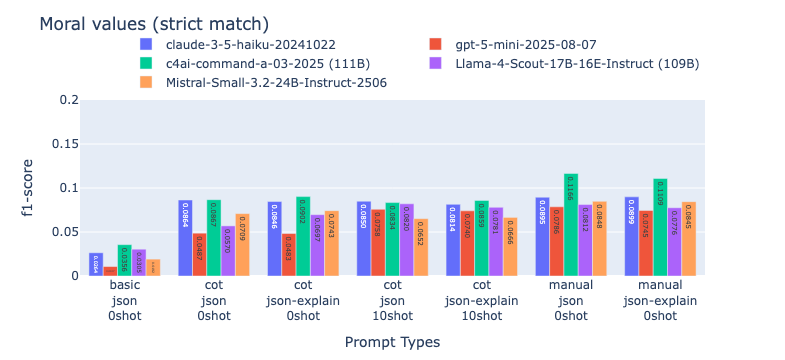

In [55]:
plot(scores['moral_values'], title="Moral values", split='all', metric='f1-score', strategy="strict", ylim=[0, 0.2])

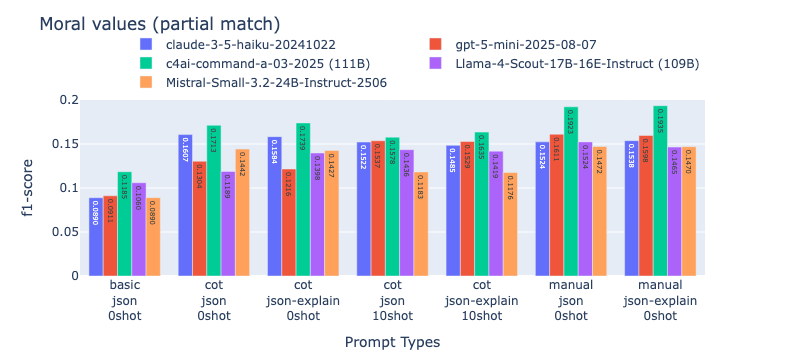

In [54]:
plot(scores['moral_values'], title="Moral values", split='all', metric='f1-score', strategy="partial", ylim=[0, 0.2])

In [20]:
from nervaluate import Evaluator
from io import StringIO
import pandas as pd


def evaluate_protagonists(df, focused_class, true_column='KAT3', pred_column='PRED_KAT3', strategy="strict"):
    class_str = focused_class if isinstance(focused_class, str) else ' '.join(focused_class)
    class_list = [focused_class] if isinstance(focused_class, str) else focused_class
    true, pred = aggregate(df, class_str, true_column=true_column, pred_column=pred_column, strategy=strategy)
    evaluator = Evaluator(true, pred, class_list, loader='list')
    dfs = []
    for mode in ["overall", "entities"]:
        x = pd.read_csv(StringIO(evaluator.results_to_csv(mode=mode, scenario="partial")), sep=",")
        x['Class'] = class_str
        dfs.append(x)
    return pd.concat(dfs).reset_index(drop=True)

In [134]:
from tqdm.auto import tqdm

experiments = [
    'basic_json_0shot',
    'cot_json_0shot',
    'cot_json-explain_0shot',
    'cot_json_10shot',
    'cot_json-explain_10shot',
    'manual_json_0shot',
    'manual_json-explain_0shot',
]
models = ['claude', 'gpt-5', 'llama', 'cohere', 'mistral']


groups = [
    'Individuum',
    'Menschen',
    'Institution',
    'Soziale-Gruppe',
    'OTHER',
]
roles = [
    'Adressat:in',
    'Benefizient:in',
    'Forderer:in',
    'Malefizient:in',
    'Bezug-unklar',
]

header = ['Strategy', 'Entity', 'Correct', 'Incorrect', 'Partial', 'Missed', 'Spurious', 'Precision', 'Recall', 'F1-Score', 'Class','Mode', 'Model', 'Split', 'Experiment']

#dfs = []
with tqdm(total=len(experiments)*len(models)*2*2) as pbar:
    for experiment in experiments:
        for model in models:
            for split in ['test', 'test-150']:
                d = df[(df.experiment == experiment) & (df.model == model) & (df.split == split)]
                assert len(d.text_id.unique()) in [150, 1584]
                
                for strategy in ['strict', 'partial']:
                    #dfs = []
                    #for role in roles:
                    #    dfs.append(evaluate_protagonists(d, focused_class=role, true_column='KAT3_role', pred_column='PRED_role', strategy=strategy))
                    #y = pd.concat(dfs).reset_index(drop=True)
                    #y['Model'] = model
                    #y['Split'] = split
                    #y['Mode'] = strategy
                    #y['Experiment'] = experiment
                    #y[header].to_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_protagonists_role_{strategy}.tsv', sep="\t", index=False)

                    #x = evaluate_protagonists(d, focused_class=groups, true_column='KAT3_group', pred_column='PRED_group', strategy=strategy)
                    #x['Class'] = 'group'
                    #x['Model'] = model
                    #x['Split'] = split
                    #x['Mode'] = strategy
                    #x['Experiment'] = experiment
                    #x[header].to_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_protagonists_group_{strategy}.tsv', sep="\t", index=False)

                    x = evaluate_protagonists(d, focused_class='Prot', true_column='KAT3_binary', pred_column='PRED_KAT3_binary', strategy=strategy)
                    x['Class'] = 'binary'
                    x['Model'] = model
                    x['Split'] = split
                    x['Mode'] = strategy
                    x['Experiment'] = experiment
                    x[header].to_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_protagonists_binary_{strategy}.tsv', sep="\t", index=False)
                    pbar.update(1)

  0%|          | 0/140 [00:00<?, ?it/s]

In [137]:
dfs = []
for experiment in experiments:
    for model in models:
        for split in ['test', 'test-150']:
            for strategy in ['strict', 'partial']:
                for target in ['role', 'group', 'binary']:
                    dfs.append(pd.read_csv(root_dir / f'data/dfs/{experiment}_{model}_{split}_protagonists_{target}_{strategy}.tsv', sep="\t", index_col=False))

x = pd.concat(dfs).reset_index(drop=True)
x[header].to_csv(root_dir / 'results/protagonists_results_testset_LREC2026.tsv', sep="\t", index=False)

In [158]:
def get_scores(match, partial):
    ret = match[data_header].sum().to_dict()
    score = compute_metrics(ret, partial=partial)
    ret.update(score)
    return ret

def get_scores_protagonist(df, scores):
    data_header = ['Correct','Incorrect','Partial','Missed','Spurious']
    for experiment in experiments:
        for model in models:
            for strategy in ["strict", "partial"]:
                match = df[(df['Mode'] == strategy) & (df['Strategy'] == strategy) & (df['Experiment'] == experiment) & (df['Model'] == model)]
                for target in ['role', 'group', 'binary']:
                    if target == 'role':
                        match_target = match[match['Class'].isin(roles)]
                    elif target == 'group':
                        match_target = match[match['Class'] == 'group']
                    elif target == 'binary':
                        match_target = match[match['Class'] == 'binary']
                    # both test and test-150
                    scores[f'protagonists_{target}'][f'{experiment}_{model}_all'][strategy] = get_scores(match_target, partial=strategy=="partial")
                    
                    for split in ["test", "test-150"]:
                        match_target = match_target[(match_target['Split'] == split)]
                        scores[f'protagonists_{target}'][f'{experiment}_{model}_{split}'][strategy] = get_scores(match_target, partial=strategy=="partial")
                    
    return scores

In [159]:
scores = get_scores_protagonist(x, scores)

In [164]:
metrics = ['Correct', 'Incorrect', 'Partial', 'Missed', 'Spurious', 'precision', 'recall','f1-score']
for target in ['role', 'group', 'binary']:
    print(f'### {target}\n')
    for model in models:
        print(f'|{model}|strategy|' + '|'.join(metrics) + '|')
        print(f'|:-----:|:------:|' + '|'.join(['---:' for m in metrics]) + '|')
        for experiment in experiments:
            for strategy in ["strict", "partial"]:
                s = scores[f'protagonists_{target}'][f'{experiment}_{model}_all'][strategy]
                print(
                    f'|{experiment}|{strategy}|'
                    + '|'.join([f'{s[m]:d}' if m[0] == m[0].upper() else f'{s[m]:.04f}' for m in metrics])
                    + '|'
                )
        print()
    print()

### role

|claude|strategy|Correct|Incorrect|Partial|Missed|Spurious|precision|recall|f1-score|
|:-----:|:------:|---:|---:|---:|---:|---:|---:|---:|---:|
|basic_json_0shot|strict|228|223|0|826|5438|0.0387|0.1785|0.0636|
|basic_json_0shot|partial|369|0|81|813|5432|0.0696|0.3242|0.1146|
|cot_json_0shot|strict|283|220|0|774|3647|0.0682|0.2216|0.1043|
|cot_json_0shot|partial|419|0|83|761|3640|0.1112|0.3646|0.1704|
|cot_json-explain_0shot|strict|271|212|0|794|3488|0.0682|0.2122|0.1033|
|cot_json-explain_0shot|partial|406|0|76|781|3486|0.1119|0.3515|0.1698|
|cot_json_10shot|strict|308|208|0|761|3562|0.0755|0.2412|0.1150|
|cot_json_10shot|partial|436|0|78|749|3558|0.1167|0.3761|0.1781|
|cot_json-explain_10shot|strict|303|219|0|755|3430|0.0767|0.2373|0.1159|
|cot_json-explain_10shot|partial|441|0|80|742|3427|0.1218|0.3808|0.1846|
|manual_json_0shot|strict|311|239|0|727|4129|0.0665|0.2435|0.1044|
|manual_json_0shot|partial|459|0|90|714|4122|0.1079|0.3990|0.1699|
|manual_json-explain_0shot|stri

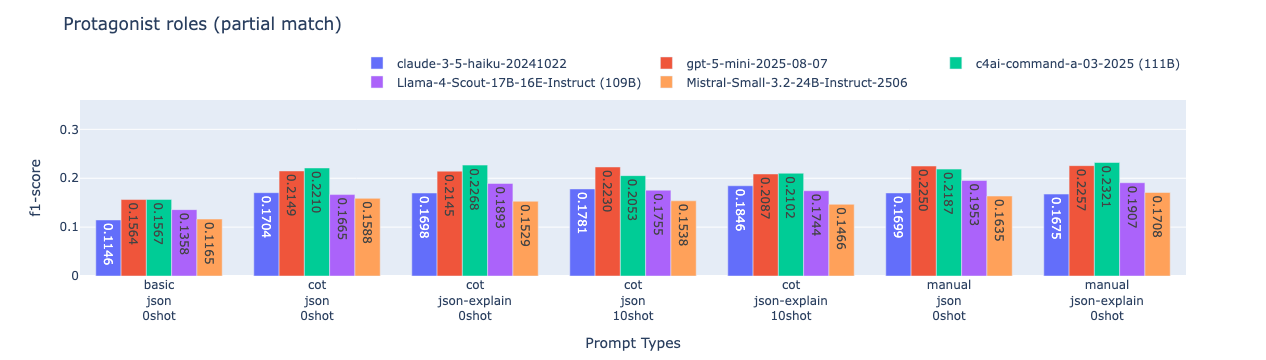

In [165]:
plot(
    scores['protagonists_role'], title="Protagonist roles",
    split='all', metric='f1-score', strategy="partial", ylim=[0, 0.36]
)

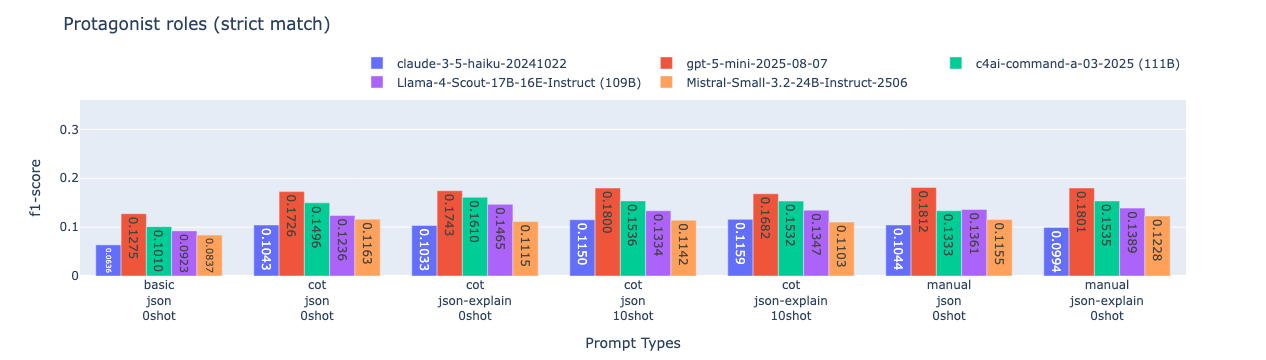

In [166]:
plot(
    scores['protagonists_role'], title="Protagonist roles",
    split='all', metric='f1-score', strategy="strict", ylim=[0, 0.36]
)

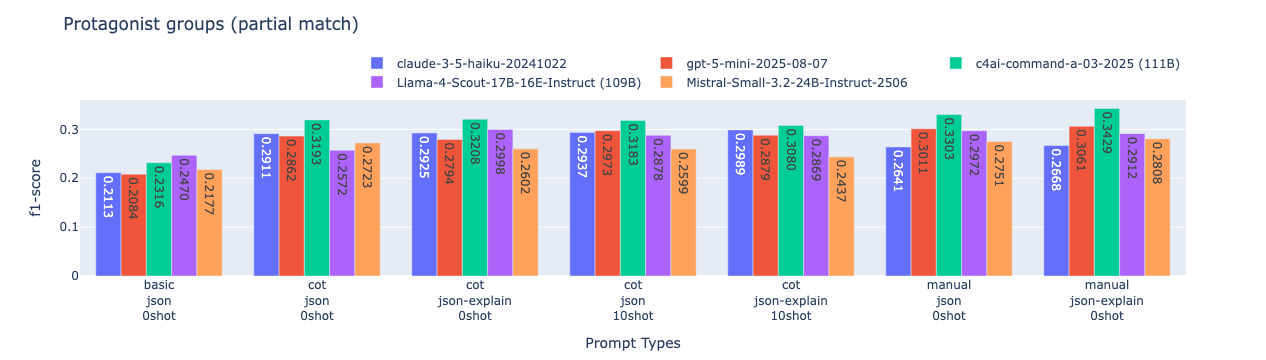

In [167]:
plot(
    scores['protagonists_group'], title="Protagonist groups",
    split='all', metric='f1-score', strategy="partial", ylim=[0, 0.36]
)

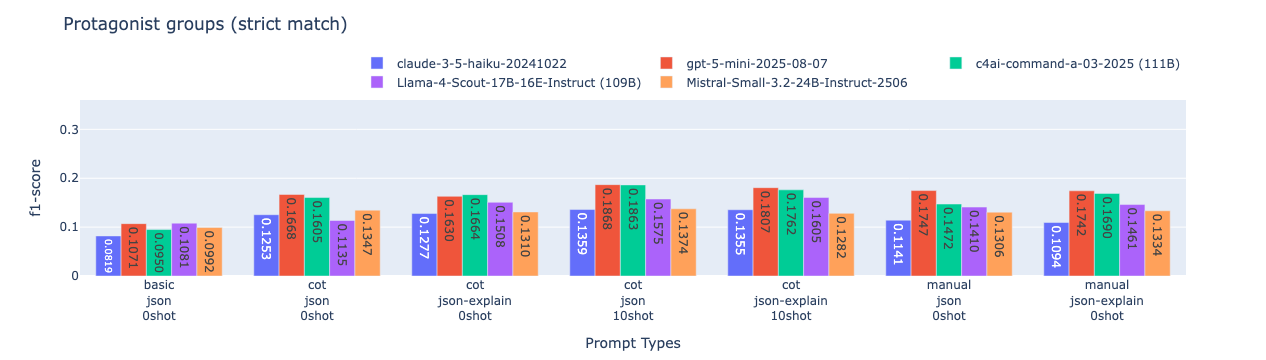

In [168]:
plot(
    scores['protagonists_group'], title="Protagonist groups",
    split='all', metric='f1-score', strategy="strict", ylim=[0, 0.36]
)

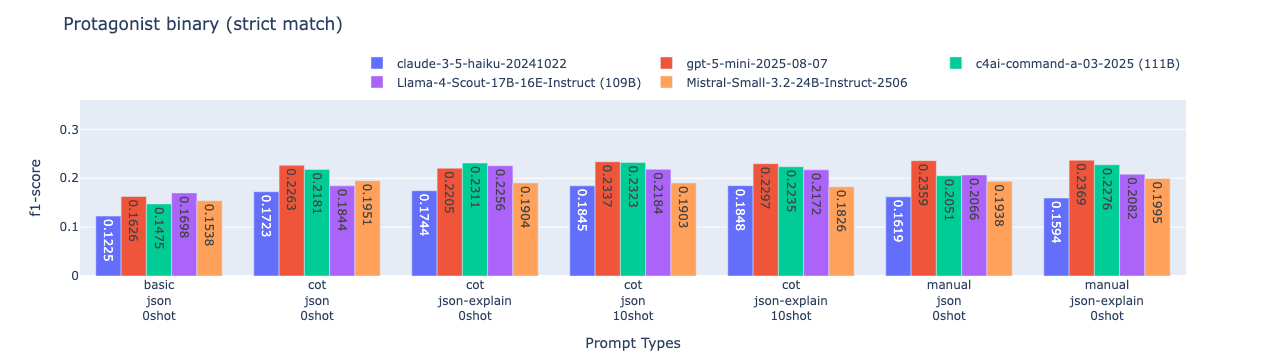

In [169]:
plot(
    scores['protagonists_binary'], title="Protagonist binary",
    split='all', metric='f1-score', strategy="strict", ylim=[0, 0.36]
)

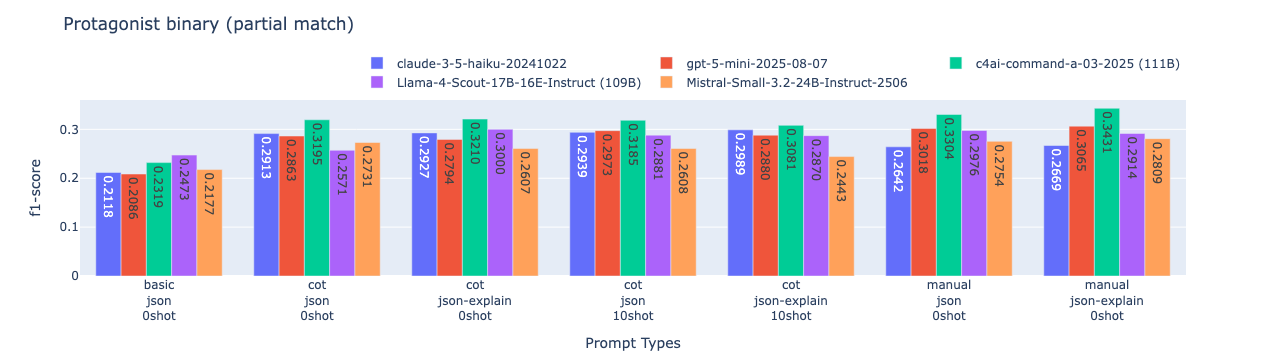

In [170]:
plot(
    scores['protagonists_binary'], title="Protagonist binary",
    split='all', metric='f1-score', strategy="partial", ylim=[0, 0.36]
)